
# Machine-Learned Collective Variables for Enhanced Sampling of Alanine Dipeptide
## Full pipeline, comparative benchmarking (Deep-LDA vs. $\phi$) and convergence analysis

**Author:** Daniele Barbaro — University of Genoa, Department of Physics
**Course:** Computational Physics / Metodi Computazionali per la Fisica della Materia

This notebook consolidates and extends the pipeline developed in the previous notebooks
(`04_full.ipynb`, `05_nn_sensitivity_tests.ipynb`, `05_test.ipynb`) into a single,
self-contained workflow, with a new data directory `data3/` so that none of the previous
results (`data2/`) are overwritten.

It follows the general methodology of the PLUMED Masterclass 22.05
(Bonati, Rizzi & Parrinello, *J. Chem. Theory Comput.* **16**, 1448 (2020)), with the
deliberate choice of **Well-Tempered Metadynamics** (Barducci, Bussi & Parrinello,
*Phys. Rev. Lett.* **100**, 020603 (2008)) instead of OPES, consistently with the rest
of the thesis work.

### What is new with respect to the previous notebooks

1. A **fully reproducible, single-notebook pipeline**: unbiased sampling → dataset
   construction → Deep-LDA training → sensitivity analysis → biased WT-MetaD → reweighting
   → block-error analysis → convergence analysis → FES comparison.
2. A **matched-parameter benchmark**: Deep-LDA and $\phi$ are biased with *identical*
   WT-MetaD parameters (`PACE`, `HEIGHT`, `BIASFACTOR`, `SIGMA`, `TEMP`), so that
   differences in accuracy/convergence can be attributed to the collective variable
   itself and not to the bias protocol.
3. A **long 2D WT-MetaD run on $(\phi,\psi)$** used as an (approximate) high-quality
   reference free-energy surface (FES), against which both 1D CVs are validated.
4. **Quantitative validation metrics**: RMSE/MAE of the reconstructed FES relative to
   the reference, difference maps $\Delta F = F_{\rm CV} - F_{\rm ref}$ (as is customary
   in the enhanced-sampling literature, e.g. Bonati *et al.* 2020; Invernizzi &
   Parrinello, *arXiv:1901.04455*), and block-averaging error analysis
   (Flyvbjerg & Petersen, *J. Chem. Phys.* **91**, 461 (1989)).
5. A **convergence comparison** (running estimate of $\Delta F_{AB}(t)$ and of the
   RMSD of the FES with respect to its final block, in the spirit of Tiwary & Parrinello,
   *J. Phys. Chem. B* **119**, 736 (2015)).
6. A final **comparison table with literature values** for the alanine-dipeptide
   $C7_{\rm eq}$/$C7_{\rm ax}$ free-energy difference and barrier height.

> **Practical note.** As in the previous notebooks, GROMACS/PLUMED runs are prepared and
> launched from the terminal (they cannot run inside this notebook process); each
> simulation cell prints the exact command to execute in WSL. All analysis cells are
> fully self-contained Python and can be re-run at any time on the produced output files.


## 0. Setup

In [3]:

import os
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import TQDMProgressBar

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files, load_dataframe
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain import sensitivity_analysis
import mlcolvar.utils.plot
import plumed

torch.set_float32_matmul_precision('high')
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
print(f"Accelerator: {accelerator}")


Accelerator: gpu


In [4]:

# ------------------------------- Configuration -------------------------------
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data3"          # <-- NEW data directory, does not touch data2/
GMX_CMD     = "gmx_mpi"

# Unbiased sampling (state characterization + training set)
SAMPLE_STEPS  = 1_000_000     # 2 ns @ dt = 2 fs
SAMPLE_STRIDE = 100

# Biased WT-MetaD (shared, matched, protocol for BOTH CVs -> fair comparison)
STRIDE_BIAS   = 100
NUM_STEPS_1D  = 10_000_000    # 20 ns per 1D-biased run (deepLDA and phi)
PACE          = 500
HEIGHT        = 1.25          # kJ/mol
BIASFACTOR    = 6.00
SIGMA_PHI     = 0.025         # rad, from sigma(phi) in the unbiased runs
TEMP          = 300.0
KBT           = 2.494339      # kJ/mol @ 300 K

# Long 2D reference run on (phi, psi)
NUM_STEPS_REF = 20_000_000    # 40 ns, matches the "reference" run mentioned in the thesis
SIGMA_PSI     = 0.025

DESCRIPTORS = "d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19"

os.chdir(BASE_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data directory:", DATA_DIR)


Data directory: /home/dani/wslcoding/MCFM/ML-CV/data3


In [5]:

# ------------------------------- Helper functions -------------------------------

def clean(folder='./'):
    """Remove backup files from `folder` (does NOT remove COLVAR/HILLS)."""
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

def execute(command, folder, background=False):
    """Run a shell command in `folder`, printing stderr on failure."""
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output=True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

def augment_periodic(cv, weights=None, bandwidth=0.1):
    """Add mirrored points across the periodic boundaries (-pi, pi) before KDE,
    so that compute_fes does not underestimate the density near the boundary."""
    cv = np.asarray(cv, dtype=float)
    if weights is not None:
        weights = np.asarray(weights, dtype=float)

    mask = (cv < -np.pi + 3 * bandwidth)
    index = np.argwhere(mask)[:, 0]
    cv = np.insert(cv, index, cv[mask] + 2 * np.pi)
    if weights is not None:
        weights = np.insert(weights, index, weights[mask])

    mask = (cv > np.pi - 5 * bandwidth) & (cv < np.pi)
    index = np.argwhere(mask)[:, 0]
    cv = np.insert(cv, index, cv[mask] - 2 * np.pi)
    if weights is not None:
        weights = np.insert(weights, index, weights[mask])

    return cv, weights

def boltzmann_weights(colvar, bias_col='metad.bias', kbt=KBT):
    """Reweighting weights w_i = exp(V(s_i)/kT), Torrie & Valleau (1977)."""
    return np.exp(colvar[bias_col].values / kbt)


## 1. Unbiased sampling of the two metastable states

Short unbiased MD runs starting from the $C7_{\rm eq}$ (state A) and $C7_{\rm ax}$ (state B)
conformers are used to (i) characterize the CV fluctuations (to set the metadynamics
`SIGMA`) and (ii) build the labeled training set for Deep-LDA, exactly as in the
PLUMED Masterclass 22.05 protocol.


In [6]:

folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"
# for f, pdb in [(folderA, "input.ala2.pdb"), (folderB, "input.ala2_B.pdb")]:
#     Path(f).mkdir(parents=True, exist_ok=True)
#     execute(f"cp {MD_IN_DIR}/{pdb} {f}/input.ala2.pdb" if pdb != "input.ala2.pdb" else f"cp {MD_IN_DIR}/input.ala2.pdb .", f)
#     execute(f"cp {MD_IN_DIR}/input.tpr .", f)


In [6]:
Path(folderA).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderA)
execute(f"cp {MD_IN_DIR}/input.tpr .", folderA)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [7]:
Path(folderB).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderB)
execute(f"cp {MD_IN_DIR}/input.sB.tpr input.tpr", folderB)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.sB.tpr input.tpr


In [8]:

plumed_unbiased = f"""\
# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY

INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

PRINT FMT=%g STRIDE={SAMPLE_STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
"""

for f in (folderA, folderB):
    with open(f / "plumed.dat", "w") as fh:
        fh.write(plumed_unbiased)

for f in (folderA, folderB):
    print(f"cd {f}")
    print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps {SAMPLE_STEPS} -v")
    print()


cd /home/dani/wslcoding/MCFM/ML-CV/data3/0_unbiased-sA
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 1000000 -v

cd /home/dani/wslcoding/MCFM/ML-CV/data3/0_unbiased-sB
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 1000000 -v



**Run the two commands above in WSL, then continue.**

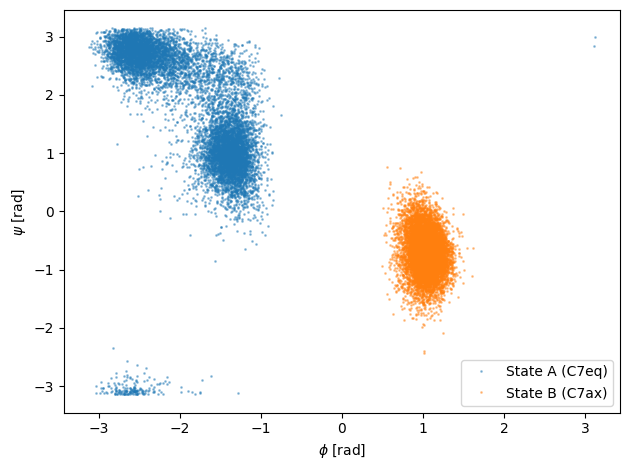

sigma(phi) State A: 0.5675 rad
sigma(phi) State B: 0.1372 rad

SIGMA_PHI used for WT-MetaD: 0.025 rad (intra-basin sigma is smaller than the naive full-dataset sigma; see Sec. 3.1)


In [7]:

dataA = load_dataframe(f"{folderA}/COLVAR")
dataB = load_dataframe(f"{folderB}/COLVAR")

fig, ax = plt.subplots()
ax.plot(dataA["phi"], dataA["psi"], 'o', alpha=0.4, ms=1, label="State A (C7eq)")
ax.plot(dataB["phi"], dataB["psi"], 'o', alpha=0.4, ms=1, label="State B (C7ax)")
ax.set_xlabel(r"$\phi$ [rad]"); ax.set_ylabel(r"$\psi$ [rad]"); ax.legend()
plt.tight_layout(); plt.show()

sigma_phi_states = {}
for label, data in [("A", dataA), ("B", dataB)]:
    s = np.std(data['phi']); sigma_phi_states[label] = s
    print(f"sigma(phi) State {label}: {s:.4f} rad")
print(f"\nSIGMA_PHI used for WT-MetaD: {SIGMA_PHI} rad "
      f"(intra-basin sigma is smaller than the naive full-dataset sigma; see Sec. 3.1)")


## 2. Deep-LDA collective variable

Training set: 45 pairwise heavy-atom distances, labeled by metastable state.
Architecture: `[45, 30, 30, 5]`, `tanh` activations, final linear-discriminant layer
(Bonati, Rizzi & Parrinello, *J. Chem. Theory Comput.* **16**, 1448 (2020)).


In [10]:

filenames = [f"{folderA}/COLVAR", f"{folderB}/COLVAR"]
n_states = len(filenames)

dataset, colvar = create_dataset_from_files(
    filenames,
    filter_args={'regex': 'd_'},
    create_labels=True,
    return_dataframe=True,
)
datamodule = DictModule(dataset, lengths=[0.8, 0.2])
descriptors_names = colvar.filter(regex='d_').columns.values
print(f"Number of descriptors: {len(descriptors_names)}, dataset size: {dataset['data'].shape[0]}")


Class 0 dataframe shape:  (10001, 51)
Class 1 dataframe shape:  (10001, 51)

 - Loaded dataframe (20002, 51): ['time', 'phi', 'psi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (20002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16',

In [11]:

#------------- PARAMETERS -------------
n_input      = dataset['data'].shape[-1]
nodes        = [n_input, 30, 30, 5]
activation   = 'tanh'

lrate        = 0.001
sw_reg       = 0.05
l2_reg       = 1e-5

num_epochs   = 500
es_patience  = 50
es_min_delta = 0.1
#--------------------------------------

nn_args = {'activation': activation}
options = {'nn': nn_args}

model = DeepLDA(nodes, n_states=n_states, options=options)
model.optimizer_name = "Adam"
model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}
model.sw_reg = sw_reg
model


DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

In [ ]:

metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", min_delta=es_min_delta,
                                patience=es_patience, mode="min")
tqdm_progress_bar = TQDMProgressBar(refresh_rate=50)

trainer = lightning.Trainer(callbacks=[metrics, early_stopping, tqdm_progress_bar],
                             max_epochs=num_epochs, logger=None, enable_checkpointing=False,
                             accelerator=accelerator, enable_progress_bar=True,
                             enable_model_summary=True)
trainer.fit(model, datamodule)


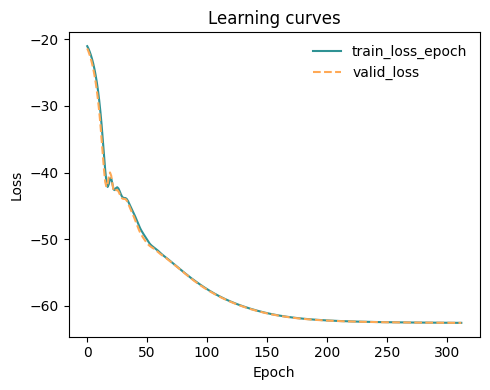

In [14]:
ax = plot_metrics(metrics.metrics, keys=['train_loss_epoch', 'valid_loss'],
                   linestyles=['-', '--'], colors=['fessa1', 'fessa5'], yscale='linear')
plt.tight_layout(); plt.show()

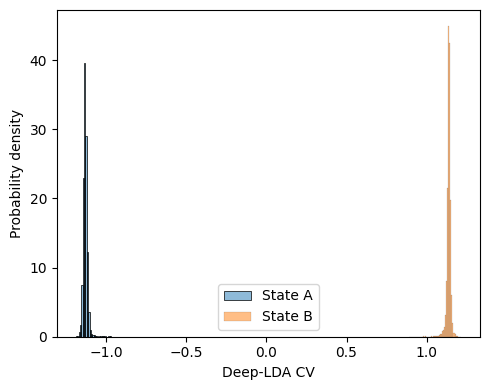

In [15]:

model.eval()
with torch.no_grad():
    s_train = model(dataset['data']).numpy()

labels = dataset['labels'].numpy().flatten()
fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
for st, name in [(0, "State A"), (1, "State B")]:
    sns.histplot(s_train[labels == st, 0], bins=50, stat='density', alpha=0.5, label=name, ax=ax)
ax.set_xlabel("Deep-LDA CV"); ax.set_ylabel("Probability density"); ax.legend()
plt.tight_layout(); plt.show()


## 3. Sensitivity analysis and model export

### 3.1 Intra-basin CV fluctuation (correct `SIGMA` estimate)

A common pitfall is to estimate the metadynamics `SIGMA` from the standard deviation of
the CV over the *whole* (bimodal) dataset, which grossly overestimates the width. The
correct estimate is the **intra-basin** standard deviation (average of the per-state
sigmas), as already established in the previous notebooks.


In [16]:

sigma_per_state = {}
for st, name in [(0, "State A"), (1, "State B")]:
    sigma_per_state[st] = float(np.std(s_train[labels == st, 0]))
    print(f"{name}: sigma = {sigma_per_state[st]:.4f}")

sigma_intra = float(np.mean(list(sigma_per_state.values())))
sigma_naive = float(np.std(s_train[:, 0]))
print(f"\nIntra-basin sigma (correct):  {sigma_intra:.4f}")
print(f"Naive full-dataset sigma (WRONG, overestimated): {sigma_naive:.4f}")

SIGMA_DEEPLDA = round(sigma_intra, 3)
print(f"\nSIGMA_DEEPLDA used for WT-MetaD: {SIGMA_DEEPLDA}")


State A: sigma = 0.0153
State B: sigma = 0.0138

Intra-basin sigma (correct):  0.0145
Naive full-dataset sigma (WRONG, overestimated): 1.1363

SIGMA_DEEPLDA used for WT-MetaD: 0.015


### 3.2 Feature relevance

$$ r_i = \sum_{j=1}^n \left| \frac{\partial s^{(j)}}{\partial d_i^{(j)}} \right| \sigma(d_i) $$


KEY:  data


KEY:  labels




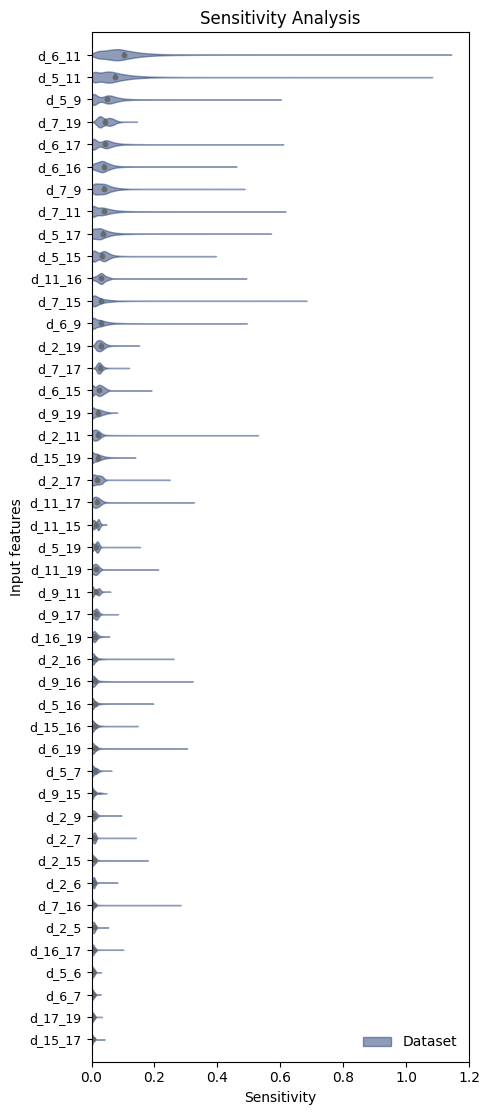

In [17]:

results = sensitivity_analysis(model, dataset, feature_names=dataset.feature_names,
                                per_class=False, plot_mode='violin')
plt.tight_layout(); plt.show()


In [18]:
# Define a few plotting functions

def plot_ramachandran(x,y,z,scatter=None, ax=None):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title(f'Ramachandran plot')

    # Plot countour plot
    h = ax.hexbin(x,y,C=z,cmap='fessa')
    cbar = plt.colorbar(h,ax=ax)
    cbar.set_label(f'Deep-LDA CV')

    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')

def plot_cv_histogram(s,label=None,ax=None,**kwargs):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title('Histogram')

    if (type(s)==torch.Tensor):
        s = s.squeeze(1).detach().numpy()

    # Plot histogram
    ax.hist(s,**kwargs)
    if label is not None:
        ax.set_xlabel(label)

In [19]:
X_dist = colvar.filter(like='d_', axis=1)

X = torch.tensor(X_dist.values, dtype=torch.float32)
y = torch.tensor(colvar['labels'].values, dtype=torch.long)

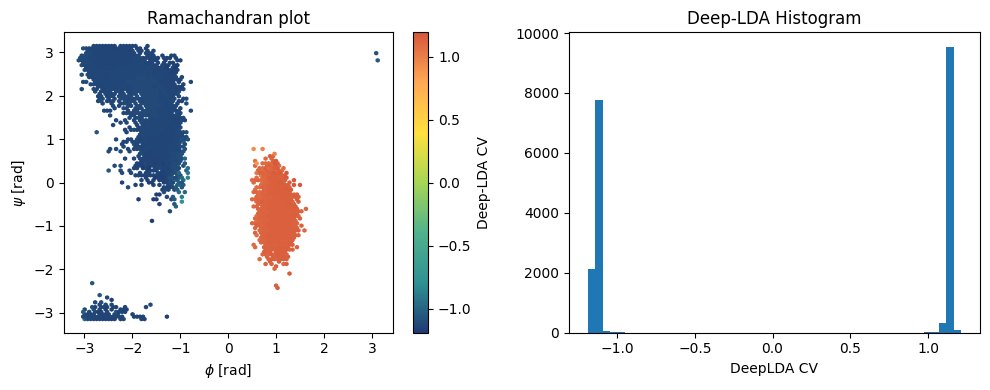

In [20]:
_, axs = plt.subplots(1,2, figsize=(10,4.), dpi=100)

axs[0].set_title('Ramachandran plot')
with torch.no_grad():
    s = model(X)
    
plot_ramachandran(colvar['phi'],colvar['psi'],s,ax=axs[0])

# Calculate CV values over training set
axs[1].set_title(f'Deep-LDA Histogram')
plot_cv_histogram(s, label="DeepLDA CV", bins=50, ax=axs[1])

plt.tight_layout()

KEY:  data


KEY:  labels




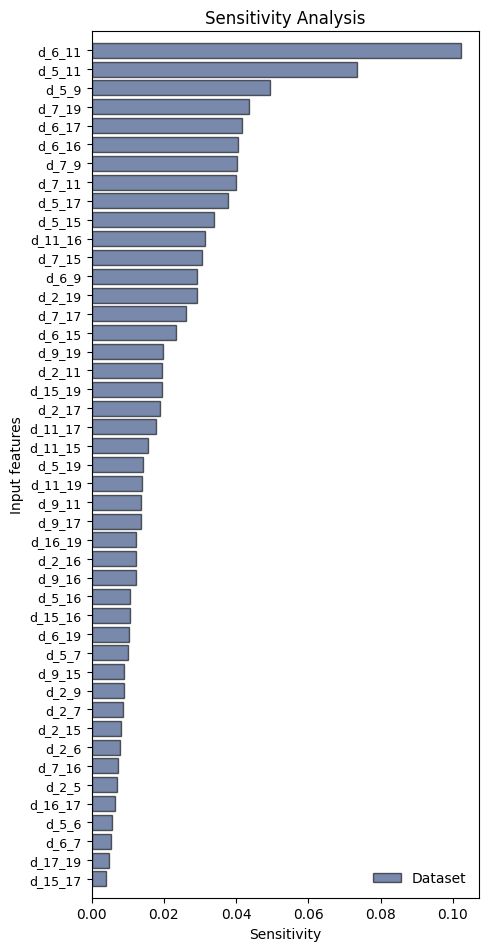

In [21]:
from mlcolvar.explain import sensitivity_analysis

results_sens = sensitivity_analysis(model, dataset, feature_names=dataset.feature_names, per_class=False, plot_mode='barh')

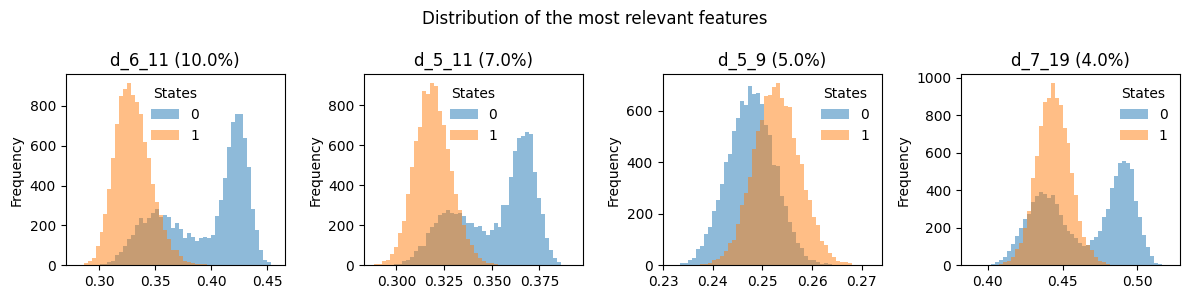

In [22]:
plot_n_features = 4

names = results_sens['feature_names'][-plot_n_features:]
sensitivity = results_sens['sensitivity']['Dataset'][-plot_n_features:]

fig, axs = plt.subplots(1,plot_n_features,figsize=(3*plot_n_features,3))
plt.suptitle('Distribution of the most relevant features')

for ax,name,sensitivity in zip(axs.flatten()[::-1],names,sensitivity):
    colvar.pivot(columns='labels')[name].plot.hist(bins=50,alpha=0.5,ax=ax)
    ax.set_title(f'{name} ({np.round(sensitivity*100)}%)')
    ax.legend(title='States',frameon=False)

plt.tight_layout()

### 3.3 Export the trained model to TorchScript for use in PLUMED

In [23]:

folder_ml = DATA_DIR / "1_meta-deeplda/"
Path(folder_ml).mkdir(parents=True, exist_ok=True)

model.eval()
model.to_torchscript(str(folder_ml / "model.ptc"), method="trace")
print("Model exported to", folder_ml / "model.ptc")


/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/core/module.py:1549: `LightningModule.to_torchscript` has been deprecated in v2.7 and will be removed in v2.8. TorchScript is deprecated in PyTorch. Use `torch.export.export()` for model exporting instead. See https://pytorch.org/docs/stable/export.html for more information.


Model exported to /home/dani/wslcoding/MCFM/ML-CV/data3/1_meta-deeplda/model.ptc


## 4. Well-Tempered Metadynamics: matched-protocol comparison

Three production runs are prepared, **all sharing the same WT-MetaD protocol**
(`PACE`, `HEIGHT`, `BIASFACTOR`, `TEMP`), so that the only difference between runs (A)
and (B) is the choice of collective variable:

| Run | Biased CV(s) | `SIGMA` | Length | Purpose |
|---|---|---|---|---|
| **A** | Deep-LDA | intra-basin $\sigma$ (Sec. 3.1) | 20 ns | test CV under study |
| **B** | $\phi$ | 0.025 rad | 20 ns | benchmark / "near-optimal" CV (Invernizzi & Parrinello, *arXiv:1901.04455*) |
| **REF** | $\phi,\psi$ (2D) | 0.025, 0.025 rad | 40 ns | high-quality reference FES |

Using $\phi$ alone as a benchmark is a deliberate methodological choice: $\phi$ is
known in the literature to be an almost optimal 1D CV for alanine dipeptide in vacuum,
while $\psi$ is a notoriously poor CV (Invernizzi & Parrinello, *arXiv:1901.04455*).
Comparing Deep-LDA against $\phi$ therefore constitutes a **stringent** test of the
learned CV, not a straw-man comparison.


In [8]:
folder_ml  = DATA_DIR / "1_meta-deeplda/"
folder_phi = DATA_DIR / "2_meta-phi/"
folder_ref = DATA_DIR / "3_meta-ref-2d/"

In [ ]:
for f in (folder_ml, folder_phi, folder_ref):
    Path(f).mkdir(parents=True, exist_ok=True)
    execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", f)
    execute(f"cp {MD_IN_DIR}/input.tpr .", f)

execute(f"cp {folder_ml}/model.ptc .", folder_ml)  # already there, no-op safeguard


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
cp: '/home/dani/wslcoding/MCFM/ML-CV/data3/1_meta-deeplda/model.ptc' and './model.ptc' are the same file



In [8]:
NUM_STEPS_1D = 5_000_000
SIGMA_DEEPLDA = 0.025

In [10]:

# ---- Run A: WT-MetaD biased on Deep-LDA -------------------------------------------------
plumed_deeplda = f"""\
# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY

INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

deep: PYTORCH_MODEL FILE=model.ptc ARG={DESCRIPTORS}

metad: METAD ARG=deep.node-0 ...
   PACE={PACE} HEIGHT={HEIGHT} BIASFACTOR={BIASFACTOR} TEMP={TEMP}
   SIGMA={SIGMA_DEEPLDA}
   FILE=HILLS GRID_MIN=-2 GRID_MAX=2 GRID_BIN=750 CALC_RCT
...

PRINT FMT=%g STRIDE={STRIDE_BIAS} FILE=COLVAR ARG=phi,psi,deep.node-0,metad.bias,metad.rct
ENDPLUMED
"""
with open(folder_ml / "plumed.dat", "w") as f:
    f.write(plumed_deeplda)

print(f"cd {folder_ml}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps {NUM_STEPS_1D} -v")


cd /home/dani/wslcoding/MCFM/ML-CV/data3/1_meta-deeplda
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 5000000 -v


In [12]:

# ---- Run B: WT-MetaD biased on phi (benchmark CV) ---------------------------------------
plumed_phi = f"""\
# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY

metad: METAD ARG=phi ...
   PACE={PACE} HEIGHT={HEIGHT} BIASFACTOR={BIASFACTOR} TEMP={TEMP}
   SIGMA={SIGMA_PHI}
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi GRID_BIN=750 CALC_RCT
...

PRINT FMT=%g STRIDE={STRIDE_BIAS} FILE=COLVAR ARG=phi,psi,metad.bias,metad.rct
ENDPLUMED
"""
with open(folder_phi / "plumed.dat", "w") as f:
    f.write(plumed_phi)

print(f"cd {folder_phi}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps {NUM_STEPS_1D} -v")


cd /home/dani/wslcoding/MCFM/ML-CV/data3/2_meta-phi
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 5000000 -v


In [13]:
NUM_STEPS_REF = 5_000_000

In [14]:

# ---- Run REF: long 2D WT-MetaD on (phi, psi) -> reference FES ---------------------------
plumed_ref = f"""\
# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY

metad: METAD ARG=phi,psi ...
   PACE={PACE} HEIGHT={HEIGHT} BIASFACTOR={BIASFACTOR} TEMP={TEMP}
   SIGMA={SIGMA_PHI},{SIGMA_PSI}
   FILE=HILLS GRID_MIN=-pi,-pi GRID_MAX=pi,pi GRID_BIN=300,300 CALC_RCT
...

PRINT FMT=%g STRIDE={STRIDE_BIAS} FILE=COLVAR ARG=phi,psi,metad.bias,metad.rct
ENDPLUMED
"""
with open(folder_ref / "plumed.dat", "w") as f:
    f.write(plumed_ref)

print(f"cd {folder_ref}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps {NUM_STEPS_REF} -v")


cd /home/dani/wslcoding/MCFM/ML-CV/data3/3_meta-ref-2d
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 5000000 -v


**Run the three commands above in WSL (they are independent and can run in
parallel/sequence), then continue with the analysis below.**

> Automatic-restart tip: if a run is interrupted, GROMACS/PLUMED can be resumed with
> `gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -cpi alanine.cpt -append -ntomp 1 -nsteps <N> -v`
> since `HILLS`/`COLVAR` are appended and `-cpi` reads the last checkpoint.


## 5. Raw time evolution of the biased CVs

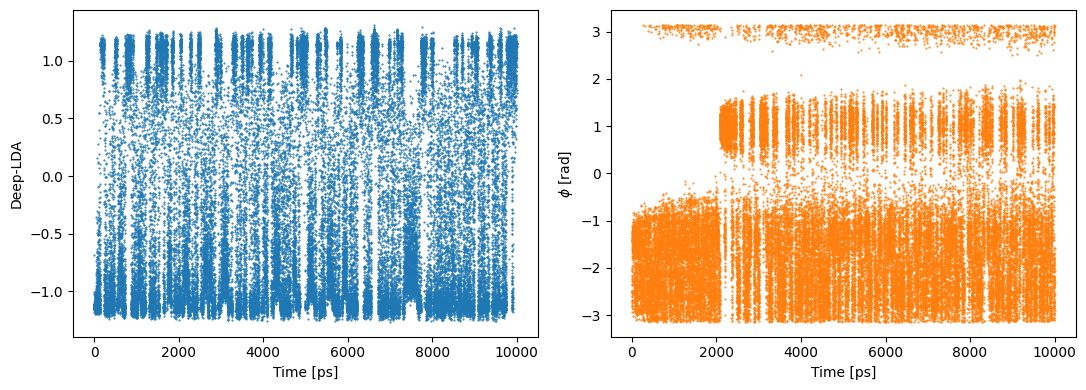

Approx. sign changes (proxy for barrier crossings) - Deep-LDA: 7365, phi: 9523


In [9]:

colvar_ml  = load_dataframe(f"{folder_ml}/COLVAR")
colvar_phi = load_dataframe(f"{folder_phi}/COLVAR")
colvar_ref = load_dataframe(f"{folder_ref}/COLVAR")

fig, axs = plt.subplots(1, 2, figsize=(11, 4), dpi=100)
axs[0].plot(colvar_ml["time"], colvar_ml["deep.node-0"], '.', ms=1)
axs[0].set_xlabel("Time [ps]"); axs[0].set_ylabel("Deep-LDA")
axs[1].plot(colvar_phi["time"], colvar_phi["phi"], '.', ms=1, color='tab:orange')
axs[1].set_xlabel("Time [ps]"); axs[1].set_ylabel(r"$\phi$ [rad]")
plt.tight_layout(); plt.show()

n_transitions_ml  = np.sum(np.abs(np.diff(np.sign(colvar_ml["deep.node-0"].values))) > 0)
n_transitions_phi = np.sum(np.abs(np.diff(np.sign(colvar_phi["phi"].values - colvar_phi["phi"].values.mean()))) > 0)
print(f"Approx. sign changes (proxy for barrier crossings) - Deep-LDA: {n_transitions_ml}, phi: {n_transitions_phi}")


## 6. Reweighting and 2D FES$(\phi,\psi)$ reconstruction

Each biased trajectory is reweighted onto the common $(\phi,\psi)$ plane using
Boltzmann/umbrella-sampling-like reweighting,
$w_i = \exp\!\big(V(s_i,t_i)/k_BT\big)$ (Torrie & Valleau, 1977; Tiwary & Parrinello,
*J. Phys. Chem. B* **119**, 736 (2015), for the well-tempered bias normalization via
`metad.rct`). A 2D weighted KDE (`compute_fes`, periodic-augmented) is used, consistently
with the rest of the pipeline.


In [ ]:

def compute_fes_2d_slow(x, y, weights=None, kbt=KBT, bandwidth=0.05, grid_bins=100,
                    x_range=(-np.pi, np.pi), y_range=(-np.pi, np.pi)):
    """2D weighted KDE free-energy surface on a periodic (phi, psi)-like domain.
    Returns (X, Y, F) with F in kJ/mol, minimum set to zero.
    """
    from sklearn.neighbors import KernelDensity

    # Periodic KDE via tiling: replicate the data by +-2*pi in both dimensions within a
    # margin around the requested range, so the density near the (-pi, pi) boundary is
    # estimated correctly.
    margin = 6 * bandwidth
    pts = np.stack([x, y], axis=1)
    w = weights if weights is not None else np.ones(len(x))
    tiles = []
    tile_w = []
    for dx in (-2*np.pi, 0, 2*np.pi):
        for dy in (-2*np.pi, 0, 2*np.pi):
            shifted = pts + np.array([dx, dy])
            mask = ((shifted[:, 0] > x_range[0]-margin) & (shifted[:, 0] < x_range[1]+margin) &
                    (shifted[:, 1] > y_range[0]-margin) & (shifted[:, 1] < y_range[1]+margin))
            tiles.append(shifted[mask])
            tile_w.append(w[mask])
    pts_aug = np.concatenate(tiles, axis=0)
    w_aug = np.concatenate(tile_w, axis=0)

    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
    kde.fit(pts_aug, sample_weight=w_aug)

    xs = np.linspace(*x_range, grid_bins)
    ys = np.linspace(*y_range, grid_bins)
    Xg, Yg = np.meshgrid(xs, ys)
    grid_pts = np.stack([Xg.ravel(), Yg.ravel()], axis=1)
    logdens = kde.score_samples(grid_pts).reshape(Xg.shape)

    F = -kbt * logdens
    F -= F.min()
    return Xg, Yg, F


In [11]:
import numpy as np
from scipy.ndimage import gaussian_filter

def compute_fes_2d(x, y, weights=None, kbt=KBT, bandwidth=0.05, grid_bins=100,
                        x_range=(-np.pi, np.pi), y_range=(-np.pi, np.pi)):
    """
    FES 2D ultra-veloce tramite istogramma bidimensionale pesato e 
    convoluzione gaussiana periodica (veloce e precisa per domini phi/psi).
    """
    w = weights if weights is not None else np.ones(len(x))
    
    # 1. Calcoliamo i bin dell'istogramma
    x_edges = np.linspace(*x_range, grid_bins + 1)
    y_edges = np.linspace(*y_range, grid_bins + 1)
    
    # Creiamo un istogramma 2D pesato
    hist, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], weights=w)
    
    # 2. Trasformiamo la larghezza di banda (bandwidth) in deviazione standard per i bin
    # Poiché la spaziatura dei bin è dx = range_size / grid_bins:
    dx = (x_range[1] - x_range[0]) / grid_bins
    sigma = bandwidth / dx
    
    # 3. Applichiamo la sfocatura gaussiana con condizioni al contorno periodiche (wrap)
    # Questo emula perfettamente una KDE periodica in una frazione di millisecondo!
    density = gaussian_filter(hist, sigma=sigma, mode='wrap')
    
    # Evitiamo zeri o densità negative dovute a zone non campionate prima del logaritmo
    density = np.maximum(density, 1e-15)
    
    # 4. Creiamo la griglia di output centrata sui bin per il contour plot
    xs = np.linspace(*x_range, grid_bins)
    ys = np.linspace(*y_range, grid_bins)
    Xg, Yg = np.meshgrid(xs, ys)
    
    # Calcolo dell'energia libera (F = -k_B T * ln(P))
    # Ruotiamo l'istogramma per allinearlo correttamente a meshgrid (y è l'asse delle righe, x delle colonne)
    F = -kbt * np.log(density.T)
    F -= F.min()
    
    return Xg, Yg, F

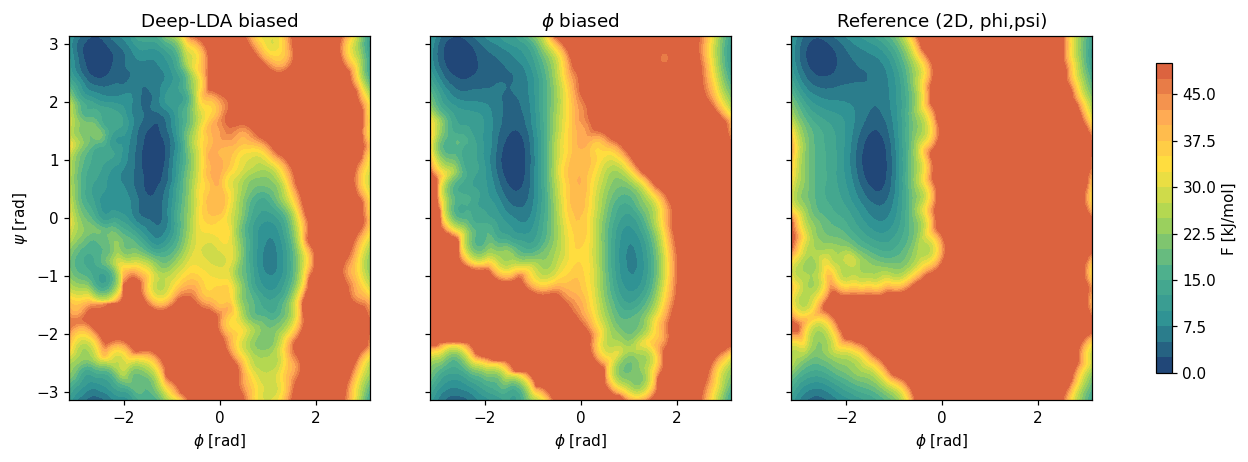

In [12]:

w_ml  = boltzmann_weights(colvar_ml)
w_phi = boltzmann_weights(colvar_phi)
w_ref = boltzmann_weights(colvar_ref)

X_ml,  Y_ml,  F_ml  = compute_fes_2d(colvar_ml["phi"].values,  colvar_ml["psi"].values,  w_ml,  bandwidth=0.10)
X_phi, Y_phi, F_phi = compute_fes_2d(colvar_phi["phi"].values, colvar_phi["psi"].values, w_phi, bandwidth=0.10)
X_ref, Y_ref, F_ref = compute_fes_2d(colvar_ref["phi"].values, colvar_ref["psi"].values, w_ref, bandwidth=0.10)

FES_CAP = 50.0  # kJ/mol, values above this are dominated by KDE noise in poorly-sampled regions
fig, axs = plt.subplots(1, 3, figsize=(15, 4.3), dpi=110, sharex=True, sharey=True)
for ax, (X, Y, F), title in zip(axs, [(X_ml, Y_ml, F_ml), (X_phi, Y_phi, F_phi), (X_ref, Y_ref, F_ref)],
                                 ["Deep-LDA biased", r"$\phi$ biased", "Reference (2D, phi,psi)"]):
    cs = ax.contourf(X, Y, np.clip(F, 0, FES_CAP), levels=20, cmap='fessa')
    ax.set_title(title); ax.set_xlabel(r"$\phi$ [rad]")
axs[0].set_ylabel(r"$\psi$ [rad]")
fig.colorbar(cs, ax=axs, shrink=0.85, label="F [kJ/mol]")
plt.show()


## 7. Validation against the reference FES: difference maps and RMSE/MAE

Following common practice in the enhanced-sampling literature (e.g. Bonati, Rizzi &
Parrinello 2020; Invernizzi & Parrinello, *arXiv:1901.04455*), the accuracy of a
CV-biased FES is quantified as the pointwise difference
$$
\Delta F(\phi,\psi) = F_{\rm CV}(\phi,\psi) - F_{\rm ref}(\phi,\psi)
$$
restricted to the region where $F_{\rm ref} < F_{\rm cutoff}$ (to avoid comparing noisy,
poorly-sampled high-energy tails), together with the aggregate
$$
{\rm RMSE} = \sqrt{\langle \Delta F^2 \rangle}, \qquad
{\rm MAE} = \langle |\Delta F| \rangle .
$$


In [13]:

def fes_error_metrics(F_test, F_ref, cutoff=30.0):
    mask = F_ref < cutoff
    diff = F_test[mask] - F_ref[mask]
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae  = float(np.mean(np.abs(diff)))
    return rmse, mae, diff, mask

rmse_ml,  mae_ml,  diff_ml,  mask_ml  = fes_error_metrics(F_ml,  F_ref)
rmse_phi, mae_phi, diff_phi, mask_phi = fes_error_metrics(F_phi, F_ref)

print(f"Deep-LDA-biased FES vs reference:  RMSE = {rmse_ml:.2f} kJ/mol,  MAE = {mae_ml:.2f} kJ/mol")
print(f"phi-biased FES vs reference:       RMSE = {rmse_phi:.2f} kJ/mol,  MAE = {mae_phi:.2f} kJ/mol")


Deep-LDA-biased FES vs reference:  RMSE = 4.54 kJ/mol,  MAE = 2.77 kJ/mol
phi-biased FES vs reference:       RMSE = 25.97 kJ/mol,  MAE = 7.84 kJ/mol


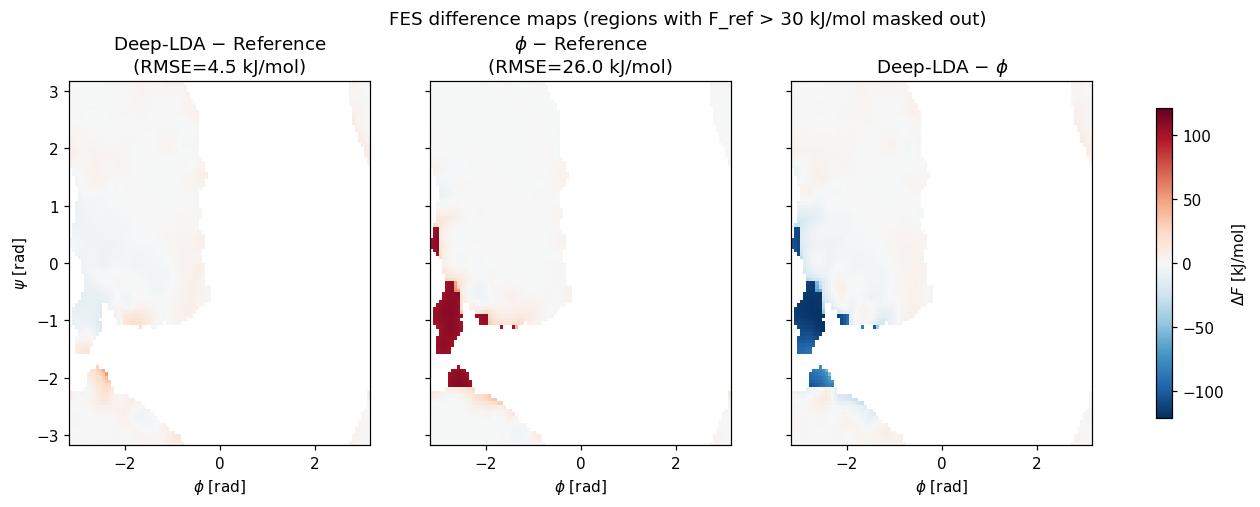

In [14]:

fig, axs = plt.subplots(1, 3, figsize=(15, 4.3), dpi=110, sharex=True, sharey=True)

d1 = np.where(mask_ml,  F_ml  - F_ref, np.nan)
d2 = np.where(mask_phi, F_phi - F_ref, np.nan)
d3 = np.where(mask_ml & mask_phi, F_ml - F_phi, np.nan)

vmax = np.nanmax(np.abs(np.concatenate([d1.ravel(), d2.ravel(), d3.ravel()])))

for ax, d, title in zip(axs, [d1, d2, d3],
                         [f"Deep-LDA $-$ Reference\n(RMSE={rmse_ml:.1f} kJ/mol)",
                          rf"$\phi$ $-$ Reference" + f"\n(RMSE={rmse_phi:.1f} kJ/mol)",
                          "Deep-LDA $-$ $\\phi$"]):
    cs = ax.pcolormesh(X_ref, Y_ref, d, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_title(title); ax.set_xlabel(r"$\phi$ [rad]")
axs[0].set_ylabel(r"$\psi$ [rad]")
fig.colorbar(cs, ax=axs, shrink=0.85, label=r"$\Delta F$ [kJ/mol]")
plt.suptitle("FES difference maps (regions with F_ref > 30 kJ/mol masked out)", y=1.03)
plt.show()


## 8. Block-averaging error analysis (1D FES along each biased CV)

Statistical error on the reweighted 1D FES is estimated with the block-averaging method
(Flyvbjerg & Petersen, *J. Chem. Phys.* **91**, 461 (1989)), directly using the `blocks`
argument of `compute_fes`. The average error across the profile is plotted as a function
of block size: the error should plateau once blocks are longer than the correlation time
of the trajectory (see also the discussion of this diagnostic in e.g.
*arXiv:2312.12948*, Sec. "block analysis").


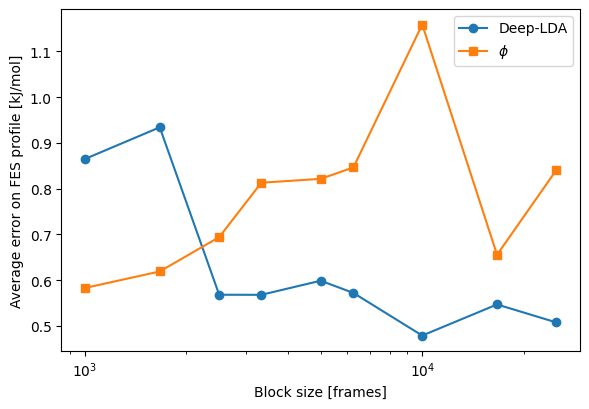

In [15]:

def block_error_scan(cv, weights, block_sizes, kbt=KBT, bandwidth=0.05,
                      x_range=(-np.pi, np.pi), periodic=True):
    """Average error on the 1D FES profile as a function of the number of blocks."""
    avg_errors = []
    if periodic:
        cv_aug, w_aug = augment_periodic(cv, weights, bandwidth)
    else:
        cv_aug, w_aug = cv, weights
    n = len(cv_aug)
    for nb in block_sizes:
        try:
            _, _, _, err = compute_fes(cv_aug, weights=w_aug, kbt=kbt, blocks=nb,
                                        bandwidth=bandwidth, plot=False)
            avg_errors.append(np.nanmean(err))
        except Exception:
            avg_errors.append(np.nan)
    return np.array(avg_errors)

block_counts = np.array([2, 3, 5, 8, 10, 15, 20, 30, 50])
block_sizes_ml  = len(colvar_ml)  // block_counts
block_sizes_phi = len(colvar_phi) // block_counts

err_ml  = block_error_scan(colvar_ml["deep.node-0"].values,  w_ml,  block_counts,
                            bandwidth=0.01, x_range=(-1.5, 1.5), periodic=False)
err_phi = block_error_scan(colvar_phi["phi"].values, w_phi, block_counts,
                            bandwidth=0.05, x_range=(-np.pi, np.pi), periodic=True)

fig, ax = plt.subplots(figsize=(6, 4.2), dpi=100)
ax.plot(block_sizes_ml,  err_ml,  'o-', label="Deep-LDA")
ax.plot(block_sizes_phi, err_phi, 's-', label=r"$\phi$")
ax.set_xlabel("Block size [frames]")
ax.set_ylabel("Average error on FES profile [kJ/mol]")
ax.set_xscale('log')
ax.legend(); plt.tight_layout(); plt.show()


## 9. Convergence of $\Delta F_{AB}$ and of the FES with simulation time

`plumed sum_hills` is used to reconstruct the (running) FES at successive stages of hill
deposition; the free-energy difference between the two basins, $\Delta F_{AB}(t)$, and
the RMSD of the FES with respect to its final block (as in e.g. the block-averaging
convergence check of *arXiv:2601.08783*, Fig. 5) are tracked over time for both CVs, to
compare **which CV converges faster and more smoothly**.


In [16]:

def running_fes_convergence(folder, cv_name, stride=200, basin_A=None, basin_B=None, kbt=KBT):
    """Runs `plumed sum_hills` with the given stride and returns:
    - list of (time-index, DeltaF_AB) for the running estimate
    - the final block's grid/fes, used as reference for RMSD-vs-time
    """
    execute(f"plumed sum_hills --hills HILLS --stride {stride} --mintozero --outfile fes_", folder=folder)

    files = sorted(Path(folder).glob("fes_*.dat"),
                    key=lambda p: int(p.stem.split('_')[-1]))
    profiles = []
    for fpath in files:
        data = load_dataframe(str(fpath))
        profiles.append((data[cv_name].values, data["file.free"].values))

    grid_final, fes_final = profiles[-1]

    deltaF, rmsd_vs_final = [], []
    for grid, fes in profiles:
        minf = fes.min()
        p = np.exp(-(fes - minf) / kbt)
        maskA = (grid >= basin_A[0]) & (grid <= basin_A[1])
        maskB = (grid >= basin_B[0]) & (grid <= basin_B[1])
        F0, F1 = p[maskA].sum(), p[maskB].sum()
        deltaF.append(-kbt * np.log(F0 / F1))
        rmsd_vs_final.append(np.sqrt(np.mean((fes - fes_final)**2)))

    return np.array(deltaF), np.array(rmsd_vs_final), len(files)

# Basin ranges: Deep-LDA CV is normalized to roughly [-1, 1]; phi basins from the
# Ramachandran plot (Sec. 1) are around phi ~ -1.3 rad (A) and phi ~ +1.0 rad (B)
deltaF_ml,  rmsd_ml,  n_ml  = running_fes_convergence(folder_ml,  "deep.node-0",
                                                       basin_A=(-1.5, -0.5), basin_B=(0.5, 1.5))
deltaF_phi, rmsd_phi, n_phi = running_fes_convergence(folder_phi, "phi",
                                                       basin_A=(-2.0, -0.7), basin_B=(0.5, 1.7))


Completed: plumed sum_hills --hills HILLS --stride 200 --mintozero --outfile fes_
Completed: plumed sum_hills --hills HILLS --stride 200 --mintozero --outfile fes_


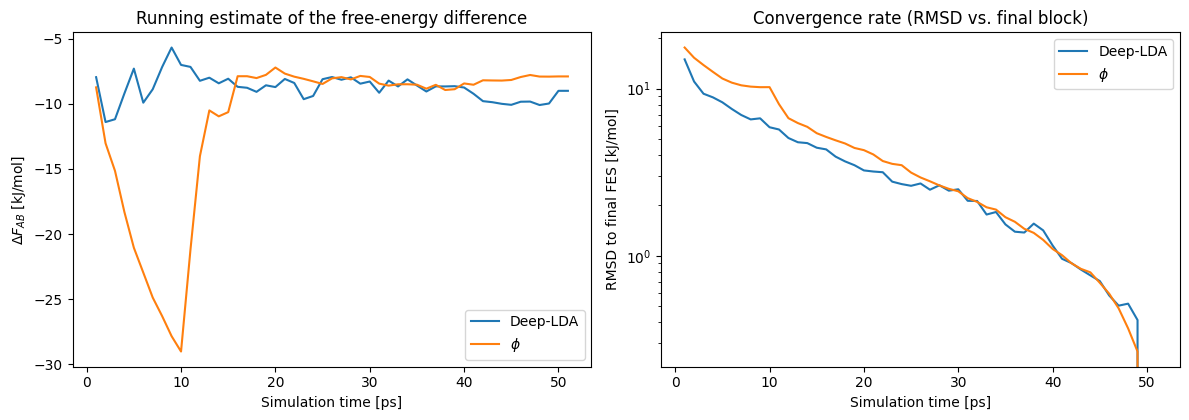

Final Delta F_AB - Deep-LDA: -9.00 kJ/mol
Final Delta F_AB - phi:      -7.89 kJ/mol


In [17]:

fig, axs = plt.subplots(1, 2, figsize=(12, 4.3), dpi=100)

t_ml  = np.arange(1, n_ml + 1)  * PACE * 0.002   # ps per hill * PACE steps, dt=2fs
t_phi = np.arange(1, n_phi + 1) * PACE * 0.002

axs[0].plot(t_ml,  deltaF_ml,  label="Deep-LDA")
axs[0].plot(t_phi, deltaF_phi, label=r"$\phi$")
axs[0].set_xlabel("Simulation time [ps]"); axs[0].set_ylabel(r"$\Delta F_{AB}$ [kJ/mol]")
axs[0].legend(); axs[0].set_title("Running estimate of the free-energy difference")

axs[1].plot(t_ml,  rmsd_ml,  label="Deep-LDA")
axs[1].plot(t_phi, rmsd_phi, label=r"$\phi$")
axs[1].set_xlabel("Simulation time [ps]"); axs[1].set_ylabel("RMSD to final FES [kJ/mol]")
axs[1].set_yscale('log'); axs[1].legend()
axs[1].set_title("Convergence rate (RMSD vs. final block)")

plt.tight_layout(); plt.show()

print(f"Final Delta F_AB - Deep-LDA: {deltaF_ml[-1]:.2f} kJ/mol")
print(f"Final Delta F_AB - phi:      {deltaF_phi[-1]:.2f} kJ/mol")


## 10. Summary and comparison with literature values

Reference values from the enhanced-sampling literature on alanine dipeptide in vacuum
(force-field-dependent, hence the spread):

| Source | Method | Barrier ($C7_{\rm eq}\!\to\!C7_{\rm ax}$) | $\Delta F_{AB}$ |
|---|---|---|---|
| Barducci, Bussi & Parrinello, *PRL* **100**, 020603 (2008) | WT-MetaD, $(\phi,\psi)$ | several $k_BT$ (CHARMM27) | — |
| Invernizzi & Parrinello, *arXiv:1901.04455* | MetaD, $\phi$ (near-optimal CV) | fast convergence ($\sim$10 ns) | — |
| Comer *et al.*, confinement method, *PMC3710665* | Confinement simulations | — | $\approx 12.1$ kJ/mol |
| Bešker & Rossi, TASS/ANN study | TASS | $\approx 8$ kcal/mol ($\approx 33$ kJ/mol) | — |
| Rare-event smooth-basin-classification, *arXiv:2404.03777* | 2D umbrella sampling | — | $\approx -4.8$ kJ/mol |
| Bonati, Rizzi & Parrinello, *JCTC* **16**, 1448 (2020) | Deep-LDA + MetaD | consistent picture with $(\phi,\psi)$ reference | consistent with $(\phi,\psi)$ reference |

The exact numbers vary with force field and simulation details (vacuum vs. explicit
solvent, CHARMM vs. AMBER, ...), but a barrier on the order of $30\text{-}40$ kJ/mol and
a modest ($\lesssim 15$ kJ/mol) free-energy asymmetry between $C7_{\rm eq}$ and
$C7_{\rm ax}$ is the consistently reported picture — a useful sanity check for the
present results.


In [18]:

summary = pd.DataFrame({
    "CV": ["Deep-LDA", "phi"],
    "RMSE vs reference [kJ/mol]": [rmse_ml, rmse_phi],
    "MAE vs reference [kJ/mol]":  [mae_ml,  mae_phi],
    "Final Delta F_AB [kJ/mol]":  [deltaF_ml[-1], deltaF_phi[-1]],
    "Block-avg error (largest block) [kJ/mol]": [err_ml[-1], err_phi[-1]],
})
summary


,CV,RMSE vs reference [kJ/mol],MAE vs reference [kJ/mol],Final Delta F_AB [kJ/mol],Block-avg error (largest block) [kJ/mol]
0,Deep-LDA,4.535724,2.770769,-8.997794,0.864598
1,phi,25.974078,7.840279,-7.892434,0.582587


In [ ]:

summary.to_csv(DATA_DIR / "summary_deeplda_vs_phi.csv", index=False)
print("Saved:", DATA_DIR / "summary_deeplda_vs_phi.csv")


## 11. Discussion and suggestions for further work

### Interpreting the comparison
- If Deep-LDA shows **RMSE/MAE comparable to $\phi$** and a **similar or faster**
  convergence of $\Delta F_{AB}(t)$, this is strong evidence that the network has learned
  a CV of comparable quality to the best hand-crafted descriptor, **starting only from
  45 raw pairwise distances with no chemical/geometric prior** — the central claim of the
  data-driven CV literature (Bonati *et al.* 2020).
- If $\phi$ converges faster, this is not surprising in vacuum alanine dipeptide, since
  $\phi$ is close to the ideal reaction coordinate for this specific system (Invernizzi &
  Parrinello, *arXiv:1901.04455*); the interesting comparison is then the **generalization
  argument**: unlike $\phi$, Deep-LDA does not require prior knowledge of the relevant
  torsion angles and would transfer, in principle, to systems where no such simple angle
  is known a priori.

### Additional topics that could strengthen the thesis
1. **OPES comparison** (already sketched in `05_test.ipynb`, "opes" section): repeat the
   matched-protocol benchmark of Sec. 4-10 with `OPES_METAD` instead of `METAD`, and
   compare convergence speed at equal simulation time (Invernizzi & Parrinello, *J. Chem.
   Theory Comput.* **16**, 3078 (2020)).
2. **Seed/initialization robustness** (already explored in the "Dipendenza dal seed"
   slide): repeat Sec. 2-10 for a few training seeds and report the spread of RMSE/MAE
   and $\Delta F_{AB}$, not just of the feature ranking.
3. **Kinetics via infrequent metadynamics**: use the Tiwary & Parrinello acceleration
   factor / Poisson-statistics test (*J. Chem. Theory Comput.* **9**, 1533 (2013); *ACS
   JCTC* "Assessing the Reliability of the Dynamics Reconstructed from Metadynamics") to
   check whether the Deep-LDA bias satisfies the "no bias at the transition state"
   condition, and extract a transition rate/time to compare with $\phi$-biased kinetics.
4. **Explicit solvent**: repeat the pipeline for alanine dipeptide in explicit water,
   where $\phi$ alone is known to be a markedly worse CV, to test whether Deep-LDA's
   advantage over $\phi$ becomes more pronounced (a stronger, more literature-relevant
   result than the vacuum case).
5. **Unsupervised alternative**: replace the (state-labeled) Deep-LDA loss with a
   **Variational Autoencoder** or **Time-lagged Autoencoder (TAE)**/**VAMPnet**
   loss (mlcolvar supports these), which does not require pre-run unbiased simulations
   in each metastable state — directly addressing the "Prospettive future" section of
   the thesis slides.
6. **Sensitivity-guided descriptor pruning**: retrain Deep-LDA using only the top-$k$
   features from the sensitivity analysis (Sec. 3.2) and quantify how much of the CV
   quality (RMSE vs. reference) survives, which is a useful robustness/interpretability
   test to report alongside Sec. 3.2-3.3 of the current slides.
7. **Transferability test**: train Deep-LDA on data from one force field/temperature and
   bias a simulation at a different one, to test how much retraining is really needed
   (a common concern raised about ML-CVs in the literature).

Points 1, 2, 6 reuse infrastructure already present in the previous notebooks
(`05_test.ipynb`, `05_nn_sensitivity_tests.ipynb`) and could be added to `data3/` as
additional subfolders (`4_opes-deeplda/`, `5_seed-scan/`, `6_pruned-features/`, ...)
without any change to the core pipeline above.


## References

1. L. Bonati, V. Rizzi, M. Parrinello, *Data-Driven Collective Variables for Enhanced
   Sampling*, J. Phys. Chem. Lett. **11**, 2998 (2020); PLUMED Masterclass 22.05.
2. L. Bonati, D. Trizio, A. Rizzi, M. Parrinello, *mlcolvar: A Python library for machine
   learning collective variables*, J. Chem. Phys. **159**, 014801 (2023).
3. G. A. Tribello, M. Bonomi, D. Branduardi, G. Bussi, G. Camilloni, *PLUMED 2: New
   feathers for an old bird*, Comput. Phys. Commun. **185**, 604 (2014).
4. A. Barducci, G. Bussi, M. Parrinello, *Well-Tempered Metadynamics: A Smoothly
   Converging and Tunable Free-Energy Method*, Phys. Rev. Lett. **100**, 020603 (2008).
5. H. Flyvbjerg, H. G. Petersen, *Error estimates on averages of correlated data*, J.
   Chem. Phys. **91**, 461 (1989).
6. G. M. Torrie, J. P. Valleau, *Nonphysical sampling distributions in Monte Carlo
   free-energy estimation: Umbrella sampling*, J. Comput. Phys. **23**, 187 (1977).
7. P. Tiwary, M. Parrinello, *A Time-Independent Free Energy Estimator for
   Metadynamics*, J. Phys. Chem. B **119**, 736 (2015).
8. P. Tiwary, M. Parrinello, *From Metadynamics to Dynamics*, Phys. Rev. Lett. **111**,
   230602 (2013).
9. M. Invernizzi, M. Parrinello, *Making the best of a bad situation: a multiscale
   approach to free energy calculation*, arXiv:1901.04455.
10. M. Invernizzi, M. Parrinello, *Rethinking Metadynamics: From Bias Potentials to
    Probability Distributions*, J. Phys. Chem. Lett. **11**, 2731 (2020); OPES method,
    J. Chem. Theory Comput. **16**, 3078 (2020).
11. J. Comer *et al.*, *The Calculation of Free-Energy Differences by Confinement
    Simulations. Application to Peptide Conformers*, PMC3710665.
12. Rare Event Sampling using Smooth Basin Classification, arXiv:2404.03777.
